# 📊 Análisis Exploratorio de Datos (EDA)
## Dataset: Students Social Media Addiction

Este análisis explora los patrones de adicción a redes sociales en estudiantes, analizando factores como:
- Uso diario de redes sociales
- Impacto en el rendimiento académico
- Salud mental y horas de sueño
- Plataformas más utilizadas
- Conflictos relacionados con redes sociales

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Configurar visualizaciones
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 1. Carga y Vista Preliminar de los Datos

In [2]:
# Cargar el dataset
df = pd.read_csv('Students Social Media Addiction.csv')

# Vista preliminar
print("📋 INFORMACIÓN GENERAL DEL DATASET")
print("="*50)
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")
print(f"\n📌 Columnas del dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print("\n🔍 Primeras 5 filas:")
df.head()

📋 INFORMACIÓN GENERAL DEL DATASET
Número de filas: 705
Número de columnas: 13

📌 Columnas del dataset:
  1. Student_ID
  2. Age
  3. Gender
  4. Academic_Level
  5. Country
  6. Avg_Daily_Usage_Hours
  7. Most_Used_Platform
  8. Affects_Academic_Performance
  9. Sleep_Hours_Per_Night
  10. Mental_Health_Score
  11. Relationship_Status
  12. Conflicts_Over_Social_Media
  13. Addicted_Score

🔍 Primeras 5 filas:


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [3]:
# Información detallada del dataset
print("📊 INFORMACIÓN DETALLADA DE LAS COLUMNAS")
print("="*50)
df.info()

📊 INFORMACIÓN DETALLADA DE LAS COLUMNAS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score          

In [4]:
# Estadísticas descriptivas de variables numéricas
print("📈 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("="*50)
df.describe().round(2)

📈 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.00,705.00,705.00,705.00,705.00,705.00,705.00
mean,353.00,20.66,4.92,6.87,6.23,2.85,6.44
std,203.66,1.40,1.26,1.13,1.11,0.96,1.59
min,1.00,18.00,1.50,3.80,4.00,0.00,2.00
25%,177.00,19.00,4.10,6.00,5.00,2.00,5.00
50%,353.00,21.00,4.80,6.90,6.00,3.00,7.00
75%,529.00,22.00,5.80,7.70,7.00,4.00,8.00
max,705.00,24.00,8.50,9.60,9.00,5.00,9.00


In [5]:
# Verificar valores nulos
print("🔎 ANÁLISIS DE VALORES NULOS")
print("="*50)
null_counts = df.isnull().sum()
null_percentage = (df.isnull().sum() / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Valores Nulos': null_counts,
    'Porcentaje (%)': null_percentage
})
print(null_df)
print(f"\n✅ Total de valores nulos en el dataset: {df.isnull().sum().sum()}")

🔎 ANÁLISIS DE VALORES NULOS
                              Valores Nulos  Porcentaje (%)
Student_ID                                0             0.0
Age                                       0             0.0
Gender                                    0             0.0
Academic_Level                            0             0.0
Country                                   0             0.0
Avg_Daily_Usage_Hours                     0             0.0
Most_Used_Platform                        0             0.0
Affects_Academic_Performance              0             0.0
Sleep_Hours_Per_Night                     0             0.0
Mental_Health_Score                       0             0.0
Relationship_Status                       0             0.0
Conflicts_Over_Social_Media               0             0.0
Addicted_Score                            0             0.0

✅ Total de valores nulos en el dataset: 0


## 2. Análisis de Variables Categóricas

In [6]:
# Análisis de variables categóricas
categorical_cols = ['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform', 
                   'Affects_Academic_Performance', 'Relationship_Status']

print("📊 DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS")
print("="*50)

for col in categorical_cols:
    print(f"\n🔹 {col}:")
    value_counts = df[col].value_counts()
    for val, count in value_counts.items():
        percentage = (count / len(df) * 100)
        print(f"   {val}: {count} ({percentage:.1f}%)")

📊 DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS

🔹 Gender:
   Female: 353 (50.1%)
   Male: 352 (49.9%)

🔹 Academic_Level:
   Undergraduate: 353 (50.1%)
   Graduate: 325 (46.1%)
   High School: 27 (3.8%)

🔹 Country:
   India: 53 (7.5%)
   USA: 40 (5.7%)
   Canada: 34 (4.8%)
   France: 27 (3.8%)
   Mexico: 27 (3.8%)
   Spain: 27 (3.8%)
   Turkey: 27 (3.8%)
   Ireland: 27 (3.8%)
   Denmark: 27 (3.8%)
   Switzerland: 27 (3.8%)
   UK: 22 (3.1%)
   Japan: 21 (3.0%)
   Italy: 21 (3.0%)
   Russia: 21 (3.0%)
   Bangladesh: 20 (2.8%)
   Maldives: 19 (2.7%)
   Sri Lanka: 19 (2.7%)
   Nepal: 19 (2.7%)
   Pakistan: 19 (2.7%)
   China: 16 (2.3%)
   Poland: 16 (2.3%)
   Germany: 14 (2.0%)
   Australia: 14 (2.0%)
   South Korea: 13 (1.8%)
   UAE: 8 (1.1%)
   Singapore: 8 (1.1%)
   New Zealand: 8 (1.1%)
   Brazil: 8 (1.1%)
   Malaysia: 8 (1.1%)
   Netherlands: 8 (1.1%)
   Finland: 8 (1.1%)
   Austria: 1 (0.1%)
   Thailand: 1 (0.1%)
   Philippines: 1 (0.1%)
   Taiwan: 1 (0.1%)
   Indonesia: 1 (0.1%)
   Hong Kon

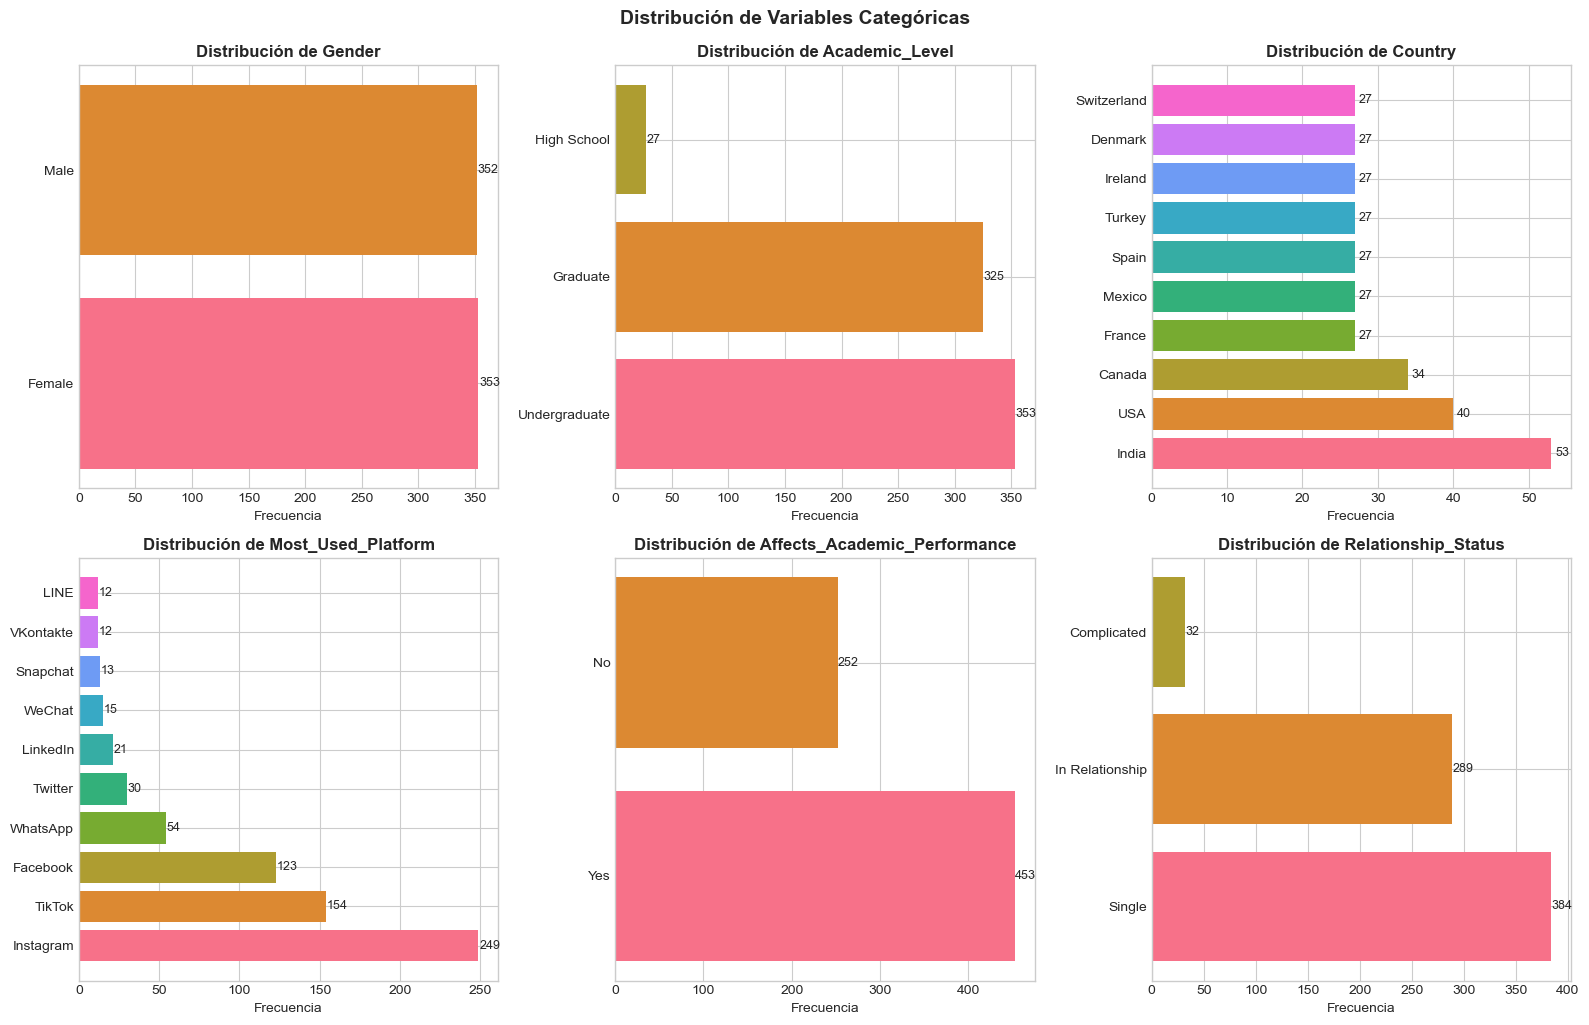

In [7]:
# Visualización de variables categóricas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = sns.color_palette("husl", 10)

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    value_counts = df[col].value_counts()
    
    if len(value_counts) > 8:
        value_counts = value_counts.head(10)
        
    bars = ax.barh(value_counts.index, value_counts.values, color=colors)
    ax.set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frecuencia')
    
    # Añadir etiquetas de valor
    for bar, val in zip(bars, value_counts.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
                str(val), va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Distribución de Variables Categóricas', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 3. Análisis de Variables Numéricas

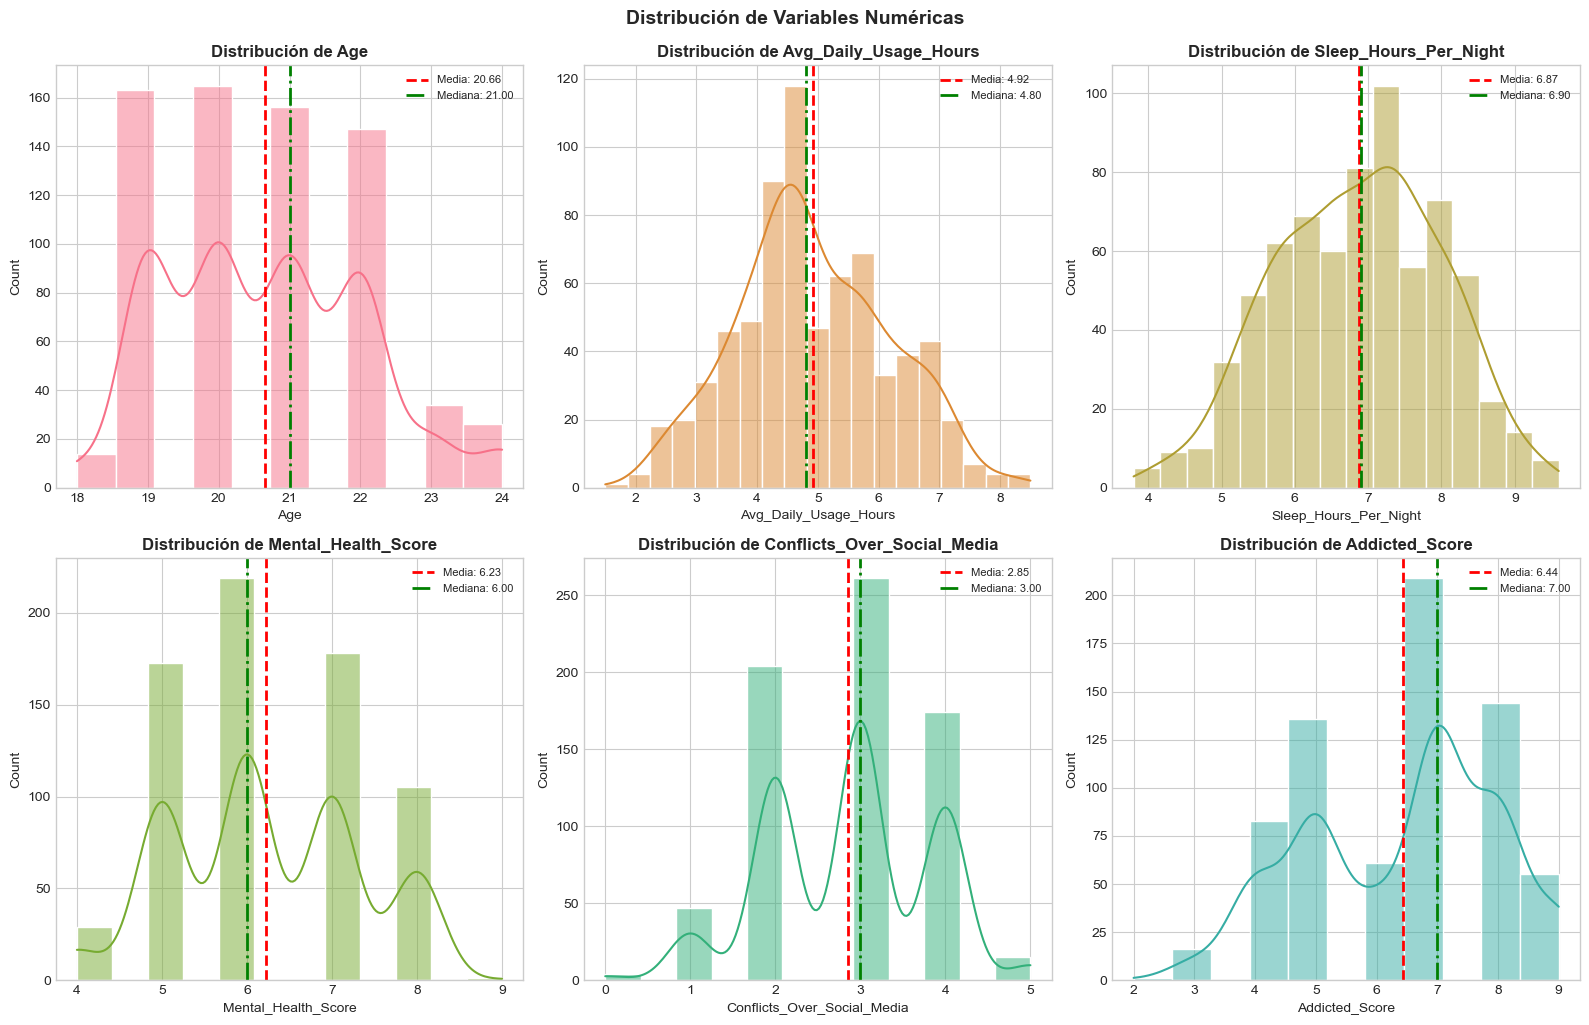

In [8]:
# Distribución de variables numéricas con histogramas
numerical_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 
                  'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    
    # Histograma con KDE
    sns.histplot(data=df, x=col, kde=True, ax=ax, color=colors[idx], edgecolor='white')
    
    # Líneas para media y mediana
    mean_val = df[col].mean()
    median_val = df[col].median()
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-.', linewidth=2, label=f'Mediana: {median_val:.2f}')
    
    ax.set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.02)
plt.show()

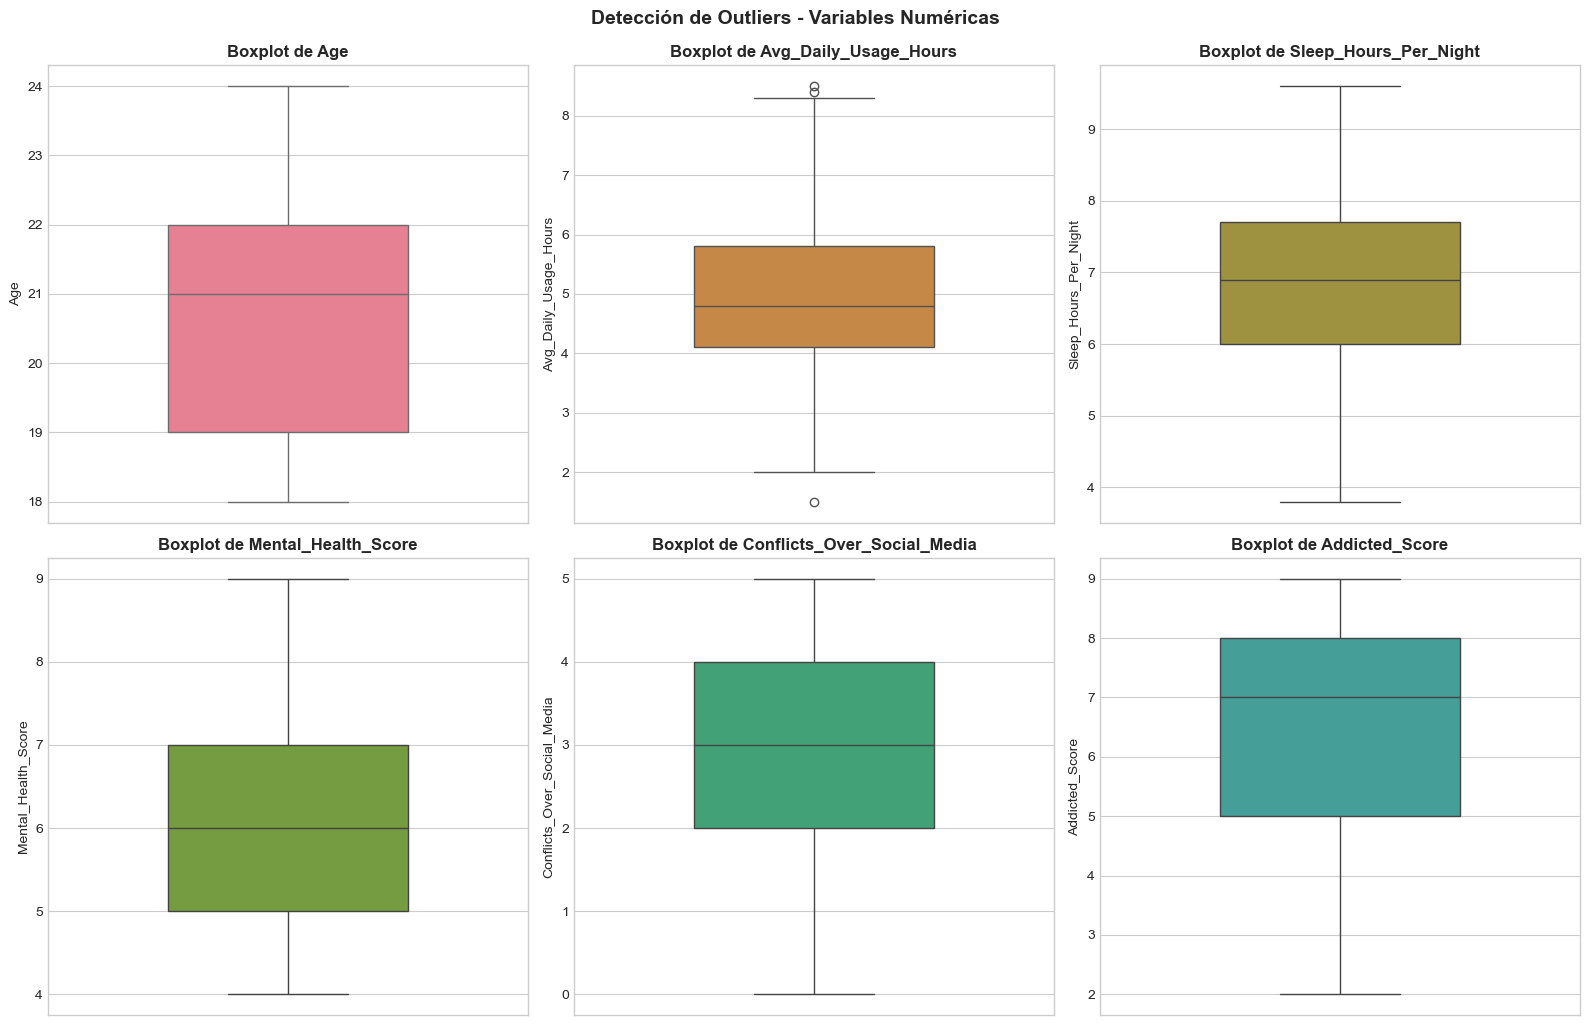

In [9]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    sns.boxplot(data=df, y=col, ax=ax, color=colors[idx], width=0.5)
    ax.set_title(f'Boxplot de {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.suptitle('Detección de Outliers - Variables Numéricas', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 4. Análisis de Correlaciones

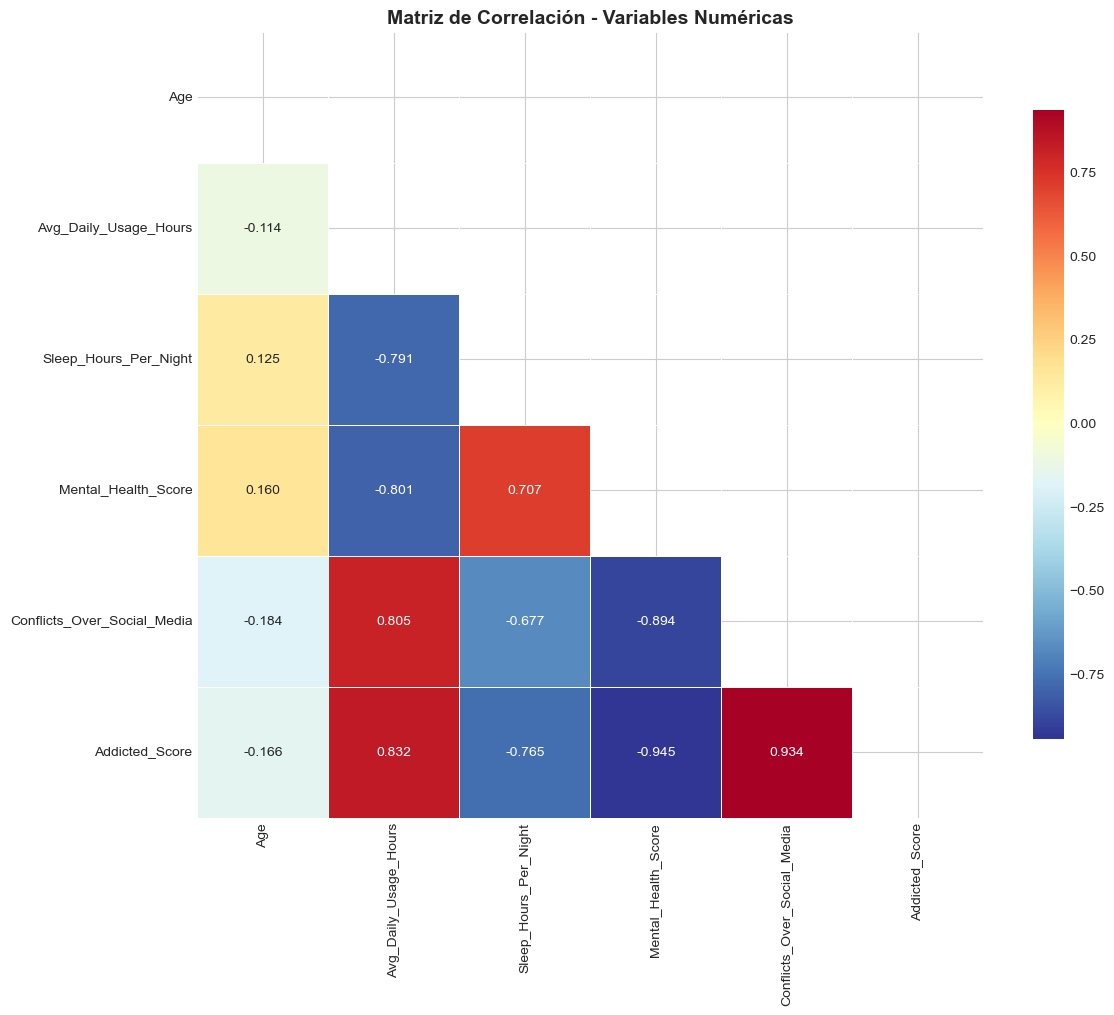


🔗 CORRELACIONES MÁS SIGNIFICATIVAS:
                 Variable 1                  Variable 2  Correlación
        Mental_Health_Score              Addicted_Score    -0.945051
Conflicts_Over_Social_Media              Addicted_Score     0.933586
        Mental_Health_Score Conflicts_Over_Social_Media    -0.893572
      Avg_Daily_Usage_Hours              Addicted_Score     0.832000
      Avg_Daily_Usage_Hours Conflicts_Over_Social_Media     0.804582
      Avg_Daily_Usage_Hours         Mental_Health_Score    -0.801058
      Avg_Daily_Usage_Hours       Sleep_Hours_Per_Night    -0.790582
      Sleep_Hours_Per_Night              Addicted_Score    -0.764858
      Sleep_Hours_Per_Night         Mental_Health_Score     0.707439
      Sleep_Hours_Per_Night Conflicts_Over_Social_Media    -0.677266


In [10]:
# Matriz de correlación
plt.figure(figsize=(12, 10))

# Seleccionar solo columnas numéricas para correlación
numeric_df = df[numerical_cols]
correlation_matrix = numeric_df.corr()

# Crear heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.3f', 
            cmap='RdYlBu_r',
            center=0,
            mask=mask,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlaciones más fuertes
print("\n🔗 CORRELACIONES MÁS SIGNIFICATIVAS:")
print("="*50)

# Obtener correlaciones ordenadas
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'Variable 1': correlation_matrix.columns[i],
            'Variable 2': correlation_matrix.columns[j],
            'Correlación': correlation_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs)
corr_df = corr_df.reindex(corr_df['Correlación'].abs().sort_values(ascending=False).index)
print(corr_df.head(10).to_string(index=False))

## 5. Análisis de Relaciones Clave

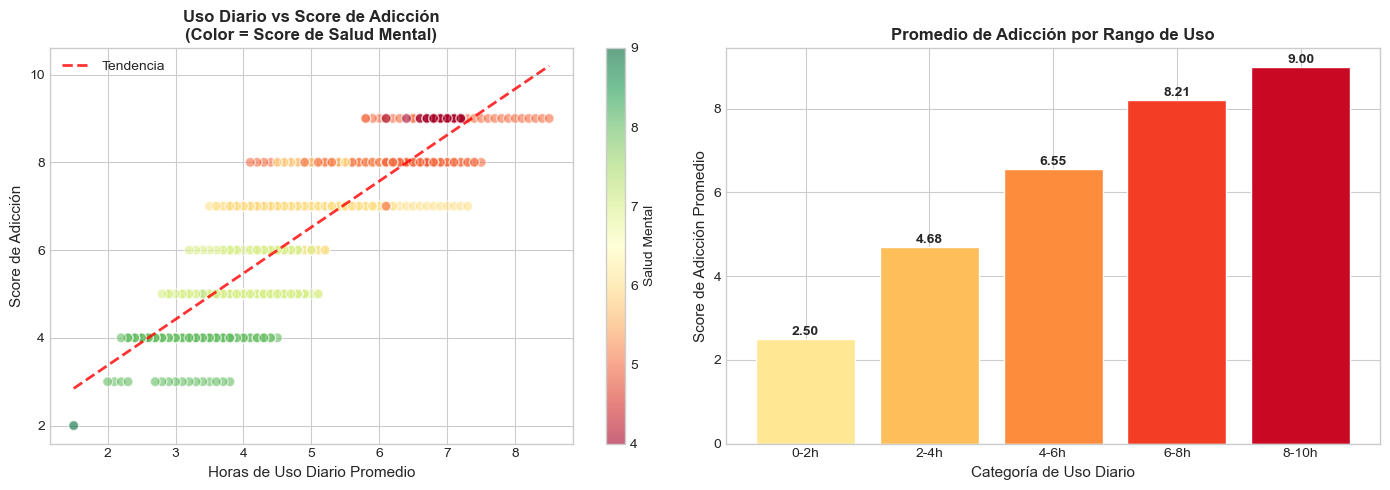

In [11]:
# Relación: Uso Diario vs Score de Adicción
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax1 = axes[0]
scatter = ax1.scatter(df['Avg_Daily_Usage_Hours'], df['Addicted_Score'], 
                      c=df['Mental_Health_Score'], cmap='RdYlGn', 
                      alpha=0.6, s=50, edgecolor='white')
ax1.set_xlabel('Horas de Uso Diario Promedio', fontsize=11)
ax1.set_ylabel('Score de Adicción', fontsize=11)
ax1.set_title('Uso Diario vs Score de Adicción\n(Color = Score de Salud Mental)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Salud Mental')

# Regresión lineal
z = np.polyfit(df['Avg_Daily_Usage_Hours'], df['Addicted_Score'], 1)
p = np.poly1d(z)
ax1.plot(df['Avg_Daily_Usage_Hours'].sort_values(), 
         p(df['Avg_Daily_Usage_Hours'].sort_values()), 
         "r--", alpha=0.8, linewidth=2, label='Tendencia')
ax1.legend()

# Promedio de adicción por rango de uso
ax2 = axes[1]
df['Usage_Category'] = pd.cut(df['Avg_Daily_Usage_Hours'], 
                               bins=[0, 2, 4, 6, 8, 10], 
                               labels=['0-2h', '2-4h', '4-6h', '6-8h', '8-10h'])
usage_addiction = df.groupby('Usage_Category', observed=True)['Addicted_Score'].mean()
bars = ax2.bar(usage_addiction.index, usage_addiction.values, color=sns.color_palette("YlOrRd", 5), edgecolor='white')
ax2.set_xlabel('Categoría de Uso Diario', fontsize=11)
ax2.set_ylabel('Score de Adicción Promedio', fontsize=11)
ax2.set_title('Promedio de Adicción por Rango de Uso', fontsize=12, fontweight='bold')

for bar, val in zip(bars, usage_addiction.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

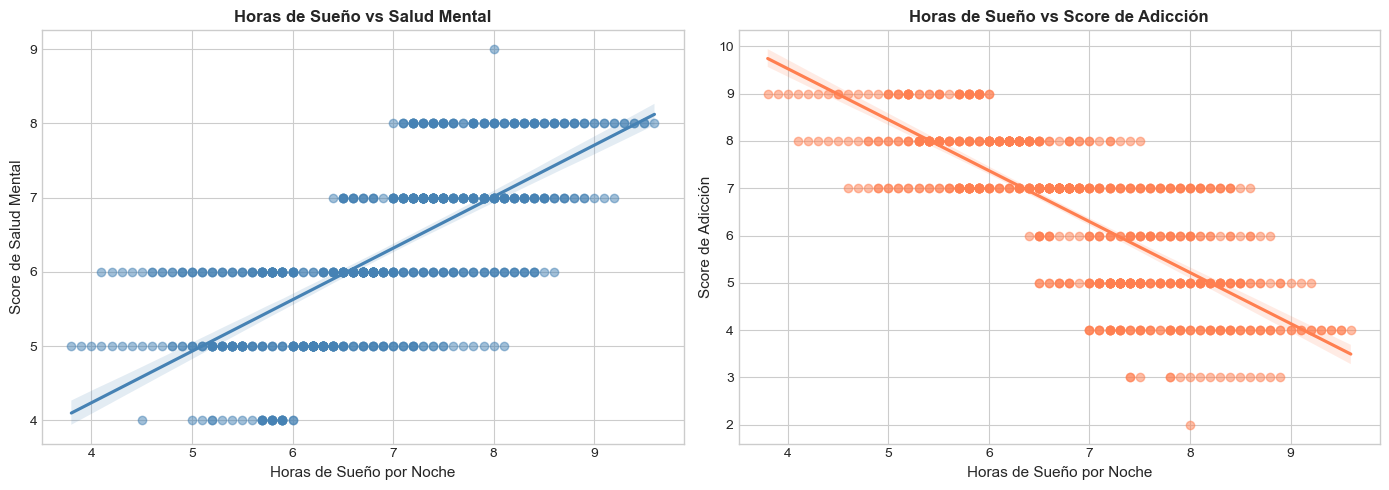

📊 ANÁLISIS: Sueño vs Salud Mental y Adicción
Correlación Sueño-Salud Mental: 0.707
Correlación Sueño-Adicción: -0.765


In [12]:
# Relación: Horas de Sueño vs Salud Mental y Adicción
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sueño vs Salud Mental
ax1 = axes[0]
sns.regplot(data=df, x='Sleep_Hours_Per_Night', y='Mental_Health_Score', 
            ax=ax1, scatter_kws={'alpha':0.5}, color='steelblue')
ax1.set_xlabel('Horas de Sueño por Noche', fontsize=11)
ax1.set_ylabel('Score de Salud Mental', fontsize=11)
ax1.set_title('Horas de Sueño vs Salud Mental', fontsize=12, fontweight='bold')

# Sueño vs Adicción
ax2 = axes[1]
sns.regplot(data=df, x='Sleep_Hours_Per_Night', y='Addicted_Score', 
            ax=ax2, scatter_kws={'alpha':0.5}, color='coral')
ax2.set_xlabel('Horas de Sueño por Noche', fontsize=11)
ax2.set_ylabel('Score de Adicción', fontsize=11)
ax2.set_title('Horas de Sueño vs Score de Adicción', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Estadísticas
print("📊 ANÁLISIS: Sueño vs Salud Mental y Adicción")
print("="*50)
corr_sleep_mental = df['Sleep_Hours_Per_Night'].corr(df['Mental_Health_Score'])
corr_sleep_addict = df['Sleep_Hours_Per_Night'].corr(df['Addicted_Score'])
print(f"Correlación Sueño-Salud Mental: {corr_sleep_mental:.3f}")
print(f"Correlación Sueño-Adicción: {corr_sleep_addict:.3f}")

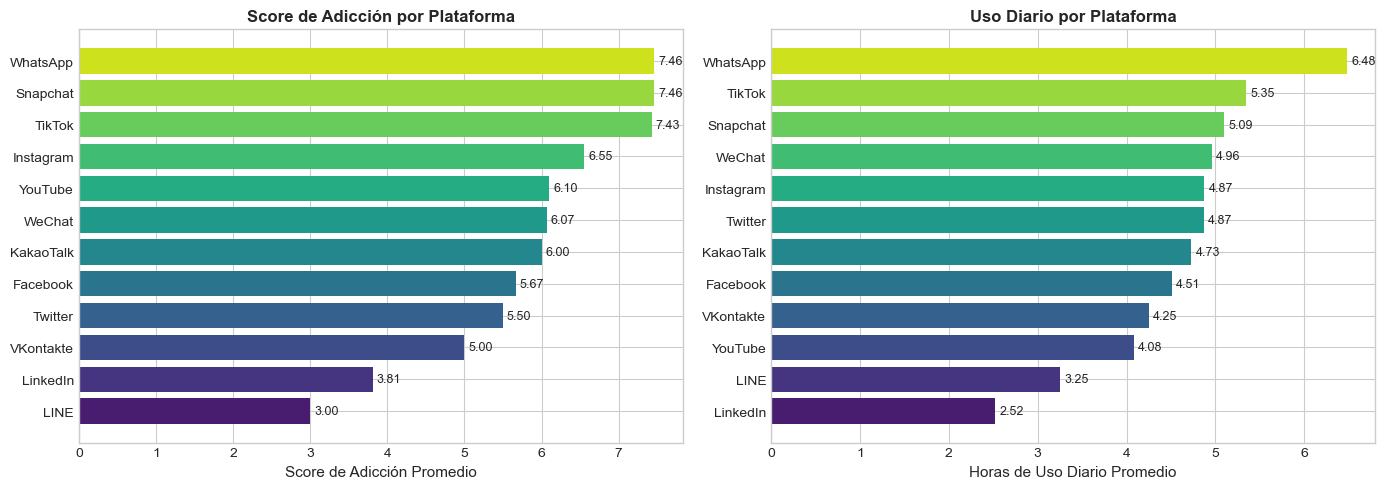

In [13]:
# Análisis por Plataforma más usada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score de adicción por plataforma
ax1 = axes[0]
platform_addiction = df.groupby('Most_Used_Platform')['Addicted_Score'].mean().sort_values(ascending=True)
colors_platform = sns.color_palette("viridis", len(platform_addiction))
bars = ax1.barh(platform_addiction.index, platform_addiction.values, color=colors_platform)
ax1.set_xlabel('Score de Adicción Promedio', fontsize=11)
ax1.set_title('Score de Adicción por Plataforma', fontsize=12, fontweight='bold')
for bar, val in zip(bars, platform_addiction.values):
    ax1.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)

# Uso diario promedio por plataforma
ax2 = axes[1]
platform_usage = df.groupby('Most_Used_Platform')['Avg_Daily_Usage_Hours'].mean().sort_values(ascending=True)
bars2 = ax2.barh(platform_usage.index, platform_usage.values, color=colors_platform)
ax2.set_xlabel('Horas de Uso Diario Promedio', fontsize=11)
ax2.set_title('Uso Diario por Plataforma', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, platform_usage.values):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

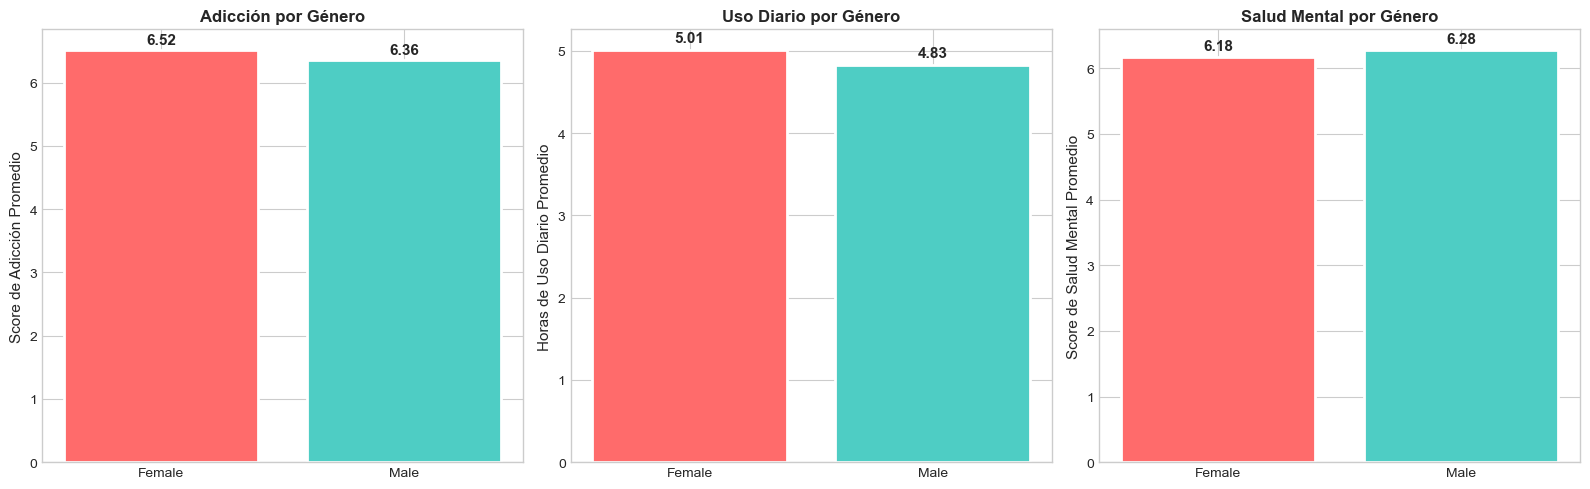

In [14]:
# Análisis por Género
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Adicción por género
ax1 = axes[0]
gender_addiction = df.groupby('Gender')['Addicted_Score'].mean()
ax1.bar(gender_addiction.index, gender_addiction.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='white', linewidth=2)
ax1.set_ylabel('Score de Adicción Promedio', fontsize=11)
ax1.set_title('Adicción por Género', fontsize=12, fontweight='bold')
for i, (idx, val) in enumerate(gender_addiction.items()):
    ax1.text(i, val + 0.1, f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

# Uso diario por género
ax2 = axes[1]
gender_usage = df.groupby('Gender')['Avg_Daily_Usage_Hours'].mean()
ax2.bar(gender_usage.index, gender_usage.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='white', linewidth=2)
ax2.set_ylabel('Horas de Uso Diario Promedio', fontsize=11)
ax2.set_title('Uso Diario por Género', fontsize=12, fontweight='bold')
for i, (idx, val) in enumerate(gender_usage.items()):
    ax2.text(i, val + 0.1, f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

# Salud mental por género
ax3 = axes[2]
gender_mental = df.groupby('Gender')['Mental_Health_Score'].mean()
ax3.bar(gender_mental.index, gender_mental.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='white', linewidth=2)
ax3.set_ylabel('Score de Salud Mental Promedio', fontsize=11)
ax3.set_title('Salud Mental por Género', fontsize=12, fontweight='bold')
for i, (idx, val) in enumerate(gender_mental.items()):
    ax3.text(i, val + 0.1, f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

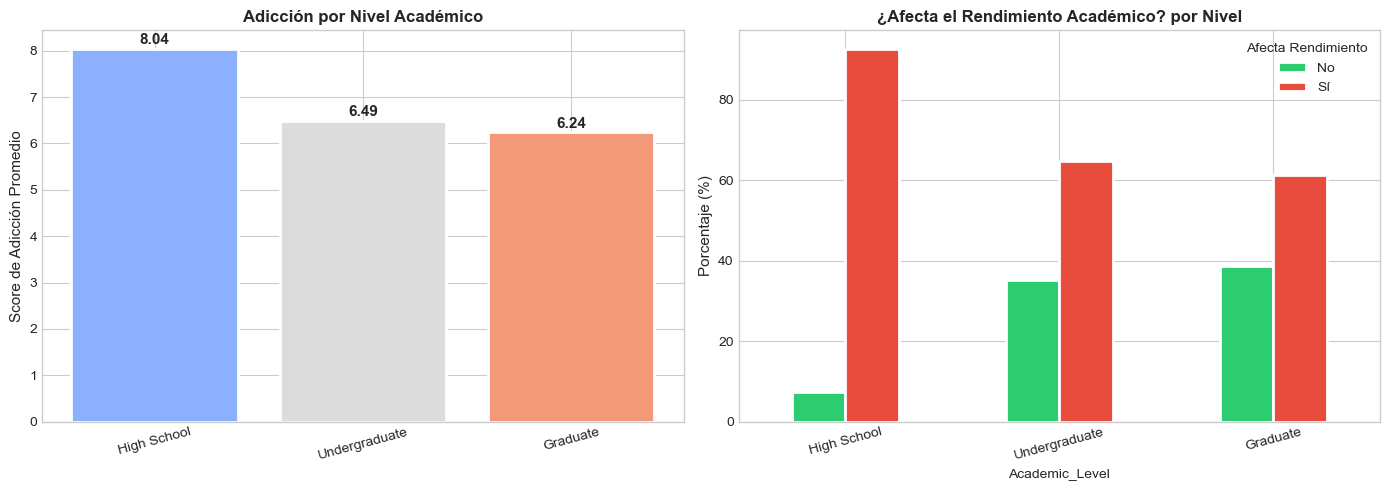

In [15]:
# Análisis por Nivel Académico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

level_order = ['High School', 'Undergraduate', 'Graduate']

# Adicción por nivel académico
ax1 = axes[0]
level_addiction = df.groupby('Academic_Level')['Addicted_Score'].mean().reindex(level_order)
bars1 = ax1.bar(level_addiction.index, level_addiction.values, 
                color=sns.color_palette("coolwarm", 3), edgecolor='white', linewidth=2)
ax1.set_ylabel('Score de Adicción Promedio', fontsize=11)
ax1.set_title('Adicción por Nivel Académico', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, level_addiction.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

# Afecta rendimiento académico por nivel
ax2 = axes[1]
affect_counts = df.groupby(['Academic_Level', 'Affects_Academic_Performance']).size().unstack(fill_value=0)
affect_counts = affect_counts.reindex(level_order)
affect_counts_pct = affect_counts.div(affect_counts.sum(axis=1), axis=0) * 100

affect_counts_pct.plot(kind='bar', ax=ax2, color=['#2ECC71', '#E74C3C'], edgecolor='white', linewidth=2)
ax2.set_ylabel('Porcentaje (%)', fontsize=11)
ax2.set_title('¿Afecta el Rendimiento Académico? por Nivel', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.legend(title='Afecta Rendimiento', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

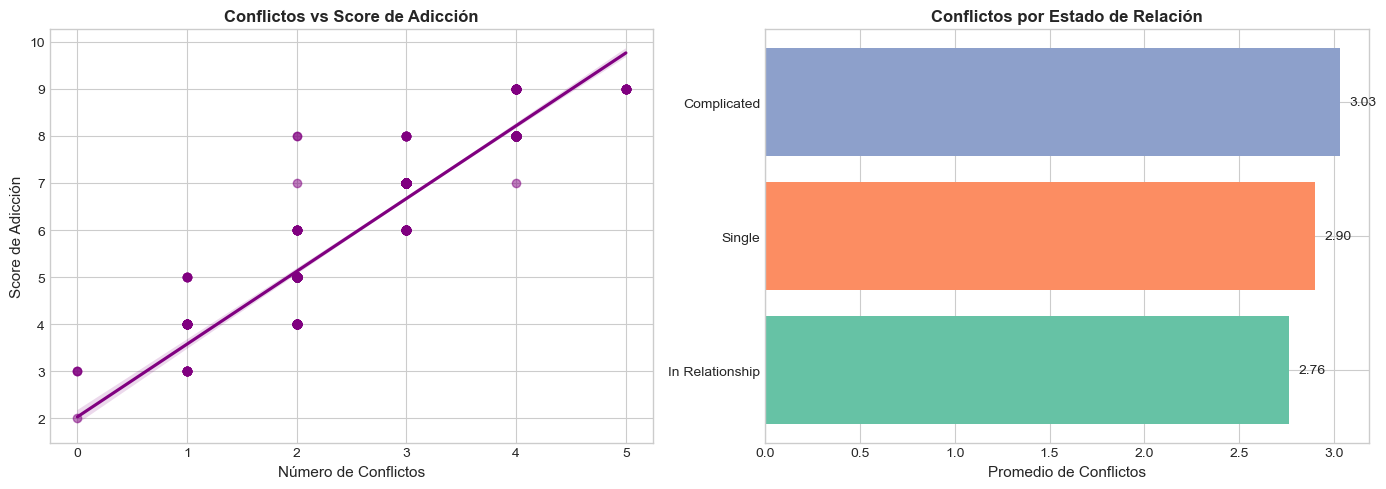

📊 Correlación Conflictos-Adicción: 0.934


In [16]:
# Análisis de Conflictos por Redes Sociales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conflictos vs Adicción
ax1 = axes[0]
sns.regplot(data=df, x='Conflicts_Over_Social_Media', y='Addicted_Score', 
            ax=ax1, scatter_kws={'alpha':0.5}, color='purple')
ax1.set_xlabel('Número de Conflictos', fontsize=11)
ax1.set_ylabel('Score de Adicción', fontsize=11)
ax1.set_title('Conflictos vs Score de Adicción', fontsize=12, fontweight='bold')

# Conflictos por estado de relación
ax2 = axes[1]
relationship_conflicts = df.groupby('Relationship_Status')['Conflicts_Over_Social_Media'].mean().sort_values()
bars = ax2.barh(relationship_conflicts.index, relationship_conflicts.values, 
                color=sns.color_palette("Set2", 3))
ax2.set_xlabel('Promedio de Conflictos', fontsize=11)
ax2.set_title('Conflictos por Estado de Relación', fontsize=12, fontweight='bold')
for bar, val in zip(bars, relationship_conflicts.values):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("📊 Correlación Conflictos-Adicción:", df['Conflicts_Over_Social_Media'].corr(df['Addicted_Score']).round(3))

## 6. Análisis Multivariado

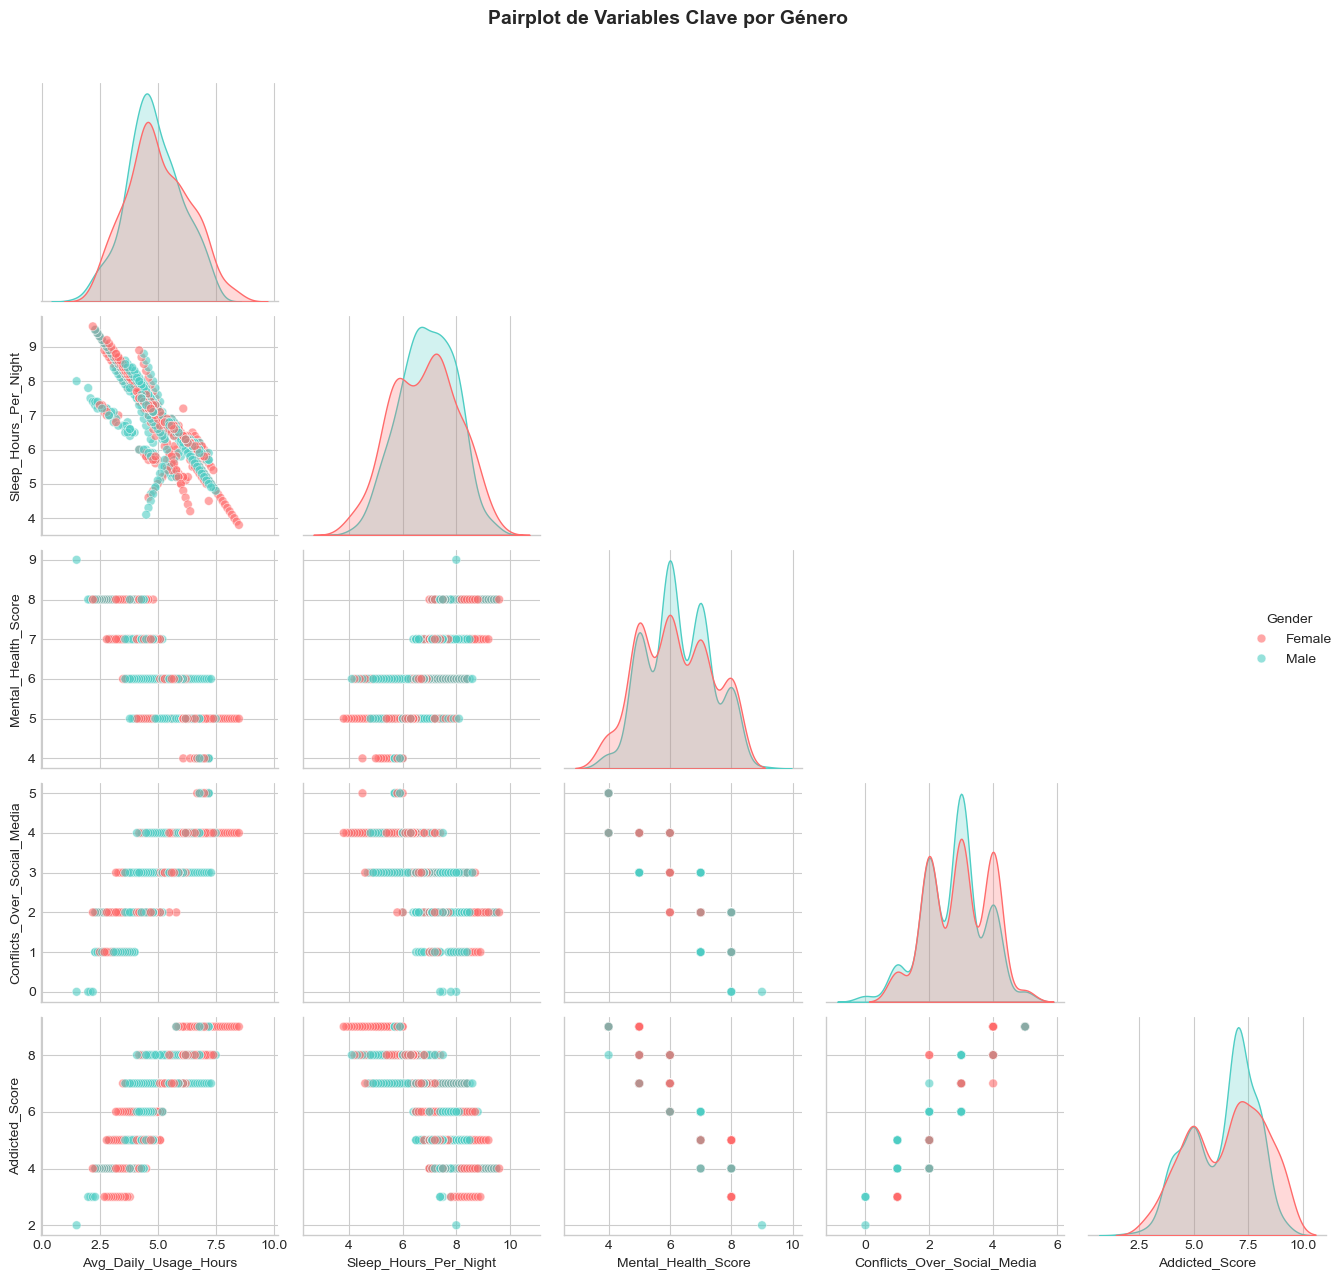

In [17]:
# Pairplot de variables clave
key_vars = ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 
            'Conflicts_Over_Social_Media', 'Addicted_Score']

g = sns.pairplot(df[key_vars + ['Gender']], hue='Gender', 
                 palette={'Male': '#4ECDC4', 'Female': '#FF6B6B'},
                 diag_kind='kde', 
                 plot_kws={'alpha': 0.6, 's': 40},
                 corner=True)

g.fig.suptitle('Pairplot de Variables Clave por Género', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

📊 PERFIL POR NIVEL DE ADICCIÓN
                 Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  \
Addiction_Level                                                 
Bajo (1-3)                        2.89                   8.14   
Medio (4-6)                       3.95                   7.76   
Alto (7-10)                       5.67                   6.21   

                 Mental_Health_Score  Conflicts_Over_Social_Media    Age  
Addiction_Level                                                           
Bajo (1-3)                      8.06                         0.76  20.24  
Medio (4-6)                     7.27                         2.04  20.86  
Alto (7-10)                     5.43                         3.49  20.54  


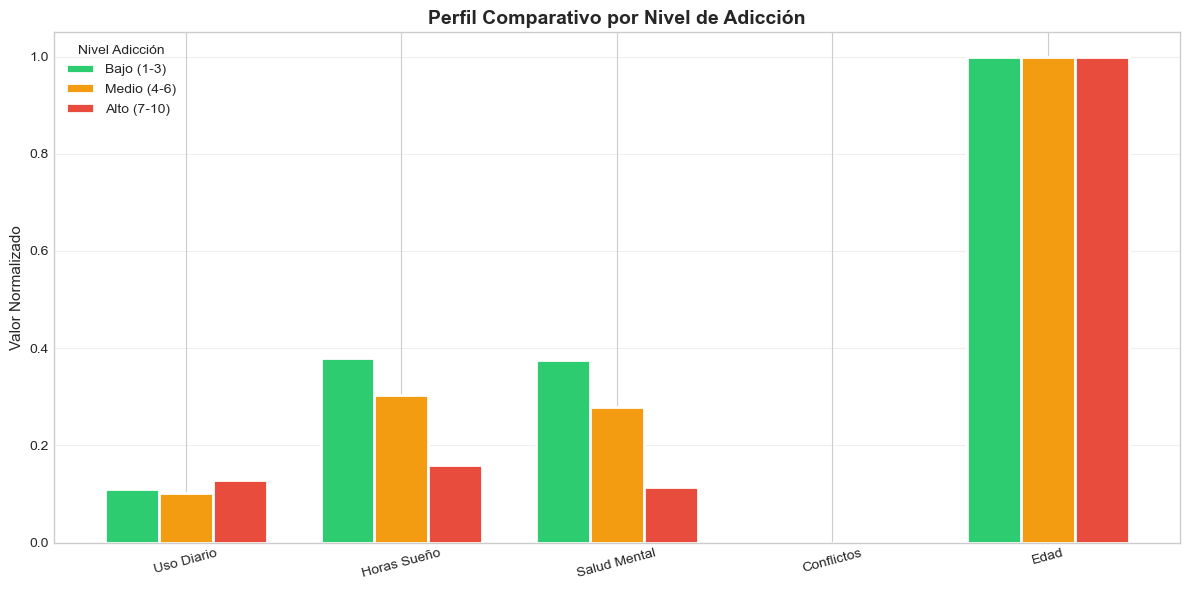

In [18]:
# Análisis de perfiles de adicción
df['Addiction_Level'] = pd.cut(df['Addicted_Score'], 
                                bins=[0, 3, 6, 10], 
                                labels=['Bajo (1-3)', 'Medio (4-6)', 'Alto (7-10)'])

# Perfil de cada nivel de adicción
profile = df.groupby('Addiction_Level', observed=True).agg({
    'Avg_Daily_Usage_Hours': 'mean',
    'Sleep_Hours_Per_Night': 'mean',
    'Mental_Health_Score': 'mean',
    'Conflicts_Over_Social_Media': 'mean',
    'Age': 'mean'
}).round(2)

print("📊 PERFIL POR NIVEL DE ADICCIÓN")
print("="*60)
print(profile)

# Visualización del perfil
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(profile.columns))
width = 0.25
multiplier = 0

colors = ['#2ECC71', '#F39C12', '#E74C3C']

for i, (level, row) in enumerate(profile.iterrows()):
    offset = width * multiplier
    # Normalizar para visualización
    normalized = (row - row.min()) / (row.max() - row.min()) if row.max() != row.min() else row
    ax.bar(x + offset, normalized, width, label=level, color=colors[i], edgecolor='white', linewidth=2)
    multiplier += 1

ax.set_ylabel('Valor Normalizado', fontsize=11)
ax.set_title('Perfil Comparativo por Nivel de Adicción', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(['Uso Diario', 'Horas Sueño', 'Salud Mental', 'Conflictos', 'Edad'], rotation=15)
ax.legend(title='Nivel Adicción')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Resumen de Patrones y Hallazgos Clave

In [19]:
# Resumen estadístico final
print("="*70)
print("📊 RESUMEN DE HALLAZGOS Y PATRONES CLAVE DEL EDA")
print("="*70)

print("\n🔹 1. CORRELACIONES MÁS SIGNIFICATIVAS:")
print("-"*50)
print(f"   • Uso Diario ↔ Adicción: {df['Avg_Daily_Usage_Hours'].corr(df['Addicted_Score']):.3f} (Fuerte positiva)")
print(f"   • Conflictos ↔ Adicción: {df['Conflicts_Over_Social_Media'].corr(df['Addicted_Score']):.3f} (Fuerte positiva)")
print(f"   • Sueño ↔ Salud Mental: {df['Sleep_Hours_Per_Night'].corr(df['Mental_Health_Score']):.3f} (Fuerte positiva)")
print(f"   • Sueño ↔ Adicción: {df['Sleep_Hours_Per_Night'].corr(df['Addicted_Score']):.3f} (Fuerte negativa)")
print(f"   • Salud Mental ↔ Adicción: {df['Mental_Health_Score'].corr(df['Addicted_Score']):.3f} (Fuerte negativa)")

print("\n🔹 2. PLATAFORMAS CON MAYOR ADICCIÓN:")
print("-"*50)
platform_rank = df.groupby('Most_Used_Platform')['Addicted_Score'].mean().sort_values(ascending=False)
for i, (platform, score) in enumerate(platform_rank.head(3).items(), 1):
    print(f"   {i}. {platform}: {score:.2f}")

print("\n🔹 3. IMPACTO EN RENDIMIENTO ACADÉMICO:")
print("-"*50)
affect_yes = df[df['Affects_Academic_Performance'] == 'Yes']
affect_no = df[df['Affects_Academic_Performance'] == 'No']
print(f"   • Estudiantes afectados: {len(affect_yes)} ({len(affect_yes)/len(df)*100:.1f}%)")
print(f"   • Promedio uso diario (afectados): {affect_yes['Avg_Daily_Usage_Hours'].mean():.2f} hrs")
print(f"   • Promedio uso diario (no afectados): {affect_no['Avg_Daily_Usage_Hours'].mean():.2f} hrs")
print(f"   • Diferencia en adicción: {affect_yes['Addicted_Score'].mean():.2f} vs {affect_no['Addicted_Score'].mean():.2f}")

print("\n🔹 4. PERFIL DEL ESTUDIANTE DE ALTO RIESGO:")
print("-"*50)
high_addiction = df[df['Addicted_Score'] >= 7]
print(f"   • Representa el {len(high_addiction)/len(df)*100:.1f}% de la muestra")
print(f"   • Uso diario promedio: {high_addiction['Avg_Daily_Usage_Hours'].mean():.2f} horas")
print(f"   • Horas de sueño promedio: {high_addiction['Sleep_Hours_Per_Night'].mean():.2f} horas")
print(f"   • Score de salud mental: {high_addiction['Mental_Health_Score'].mean():.2f}/10")
print(f"   • Plataforma más común: {high_addiction['Most_Used_Platform'].mode().values[0]}")

print("\n🔹 5. DIFERENCIAS POR GÉNERO:")
print("-"*50)
for gender in df['Gender'].unique():
    g_data = df[df['Gender'] == gender]
    print(f"   • {gender}:")
    print(f"     - Uso diario: {g_data['Avg_Daily_Usage_Hours'].mean():.2f} hrs")
    print(f"     - Adicción: {g_data['Addicted_Score'].mean():.2f}")
    print(f"     - Salud mental: {g_data['Mental_Health_Score'].mean():.2f}")

print("\n🔹 6. NIVEL ACADÉMICO Y ADICCIÓN:")
print("-"*50)
for level in ['High School', 'Undergraduate', 'Graduate']:
    l_data = df[df['Academic_Level'] == level]
    print(f"   • {level}: Adicción promedio = {l_data['Addicted_Score'].mean():.2f}")

print("\n" + "="*70)
print("✅ ANÁLISIS EDA COMPLETADO")
print("="*70)

📊 RESUMEN DE HALLAZGOS Y PATRONES CLAVE DEL EDA

🔹 1. CORRELACIONES MÁS SIGNIFICATIVAS:
--------------------------------------------------
   • Uso Diario ↔ Adicción: 0.832 (Fuerte positiva)
   • Conflictos ↔ Adicción: 0.934 (Fuerte positiva)
   • Sueño ↔ Salud Mental: 0.707 (Fuerte positiva)
   • Sueño ↔ Adicción: -0.765 (Fuerte negativa)
   • Salud Mental ↔ Adicción: -0.945 (Fuerte negativa)

🔹 2. PLATAFORMAS CON MAYOR ADICCIÓN:
--------------------------------------------------
   1. WhatsApp: 7.46
   2. Snapchat: 7.46
   3. TikTok: 7.43

🔹 3. IMPACTO EN RENDIMIENTO ACADÉMICO:
--------------------------------------------------
   • Estudiantes afectados: 453 (64.3%)
   • Promedio uso diario (afectados): 5.54 hrs
   • Promedio uso diario (no afectados): 3.80 hrs
   • Diferencia en adicción: 7.46 vs 4.60

🔹 4. PERFIL DEL ESTUDIANTE DE ALTO RIESGO:
--------------------------------------------------
   • Representa el 57.9% de la muestra
   • Uso diario promedio: 5.67 horas
   • Horas d